# O que é Churn?

### Churn é a taxa de cancelamento ou evasão de clientes de uma empresa em um período específico.

---

## Etapa 1 — Importar bibliotecas

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Configuração visual
pd.set_option('display.max_columns', None)

-------------------------------------------------------------------------------------

## Etapa 2 — Carregar o dataset

In [2]:
df = pd.read_csv('../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv')

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


-------------------------------------------------------------------------------------

## Etapa 3 — Entender os dados

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [4]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


-------------------------------------------------------------------------------------

## Etapa 4 — Verificar dados faltantes

In [5]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

-------------------------------------------------------------------------------------

## Etapa 5 — Quantos clientes existem?

In [6]:
total_clientes = df.shape[0]

print(f'Total de clientes: {total_clientes}')

Total de clientes: 7043


-------------------------------------------------------------------------------------

## Etapa 6 — Qual a taxa de churn?

In [7]:
df['Churn'].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

---

## Etapa 7 — Quem cancela mais?

### 7.1 Por gênero

In [8]:
pd.crosstab(df['gender'], df['Churn'], normalize='index') * 100

Churn,No,Yes
gender,,
Female,73.079128,26.920872
Male,73.839662,26.160338


### 7.2 Por tipo de contrato

In [9]:
pd.crosstab(df['Contract'], df['Churn'], normalize='index') * 100

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


### 7.3 Por tipo de internet

In [10]:
pd.crosstab(df['InternetService'], df['Churn'], normalize='index') * 100

Churn,No,Yes
InternetService,,
DSL,81.040892,18.959108
Fiber optic,58.107235,41.892765
No,92.595020,7.404980


## Etapa 8 — Ticket médio de quem cancelou

In [11]:
df.groupby('Churn')['MonthlyCharges'].mean()

Churn
No     61.265124
Yes    74.441332
Name: MonthlyCharges, dtype: float64

Pergunta de negócio:

Clientes que cancelam pagam mais ou menos? 

Como podemos ver, clientes que cancelam pagavam mais. Isso é uma alerta para a empresa.

---

## Etapa 9 — Descobrir possíveis fatores do churn

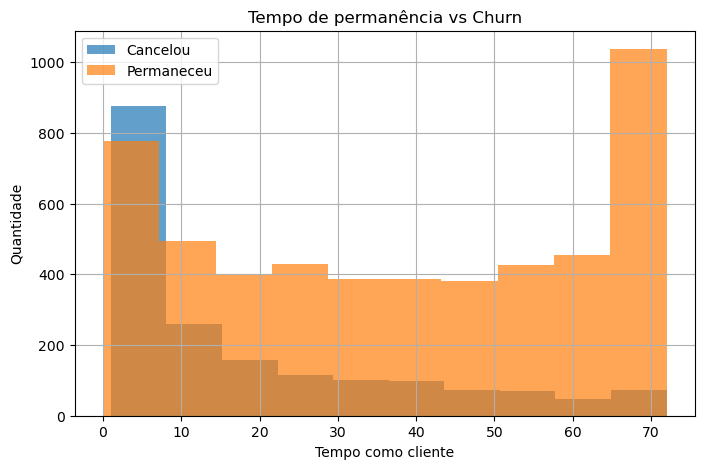

In [12]:
plt.figure(figsize=(8,5))

df[df['Churn']=='Yes']['tenure'].hist(alpha=0.7, label='Cancelou')
df[df['Churn']=='No']['tenure'].hist(alpha=0.7, label='Permaneceu')

plt.legend()
plt.xlabel('Tempo como cliente')
plt.ylabel('Quantidade')
plt.title('Tempo de permanência vs Churn')
plt.show()

Quem cancela mais?

clientes novos?
clientes antigos?

A resposta correta com base nos dados seriam que clientes novos cancelam mais.

---

## Resumo

Quantos clientes existem? 7043 

Qual % de churn? representa aproximadamente 26,53% 

O que você percebeu sobre contrato? Que pessoas com contrato month-to-month cancelam mais 

O que percebeu sobre tenure(estabilidade)? Clientes com menor tenure apresentaram maior probabilidade de churn, sugerindo que o risco de cancelamento é mais elevado nos primeiros meses do relacionamento. 

Algo te chamou atenção? Os dados sugerem que a retenção inicial representa um fator crítico para redução do churn, já que clientes com maior tempo de permanência demonstram menor propensão ao cancelamento.